In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [28]:
# my file
file1 = "/home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/batch_output/sample_granule_20240830T131442_new_chl_retrieval_full_parallel.nc"
# read the data
ds = xr.open_dataset(file1)
# loc
lat = ds['latitude'].values
lon = ds['longitude'].values
# sif coeff.
sif_ev1 = ds['sif_ev1'].values
# state variables
x_hat = ds['x_hat'].values
# reconstructed SIF at 687.2
sif_recon = ds['sif_radiance_678nm'].values

In [29]:
ds

<xarray.Dataset> Size: 215MB
Dimensions:             (scans: 1710, pixels: 1272, state: 15, sif_nev: 1)
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables: (12/16)
    latitude            (scans, pixels) float32 9MB 46.34 46.36 ... 70.22 70.22
    longitude           (scans, pixels) float32 9MB -31.07 -30.98 ... 8.347
    x_hat               (state, scans, pixels) float32 131MB nan ... nan
    converged           (scans, pixels) uint8 2MB ...
    status_code         (scans, pixels) int16 4MB ...
    n_steps             (scans, pixels) int16 4MB ...
    ...                  ...
    sif_coeffs          (sif_nev, scans, pixels) float32 9MB ...
    sif_radiance_678nm  (scans, pixels) float32 9MB nan 0.4528 ... nan nan
    is_dark             (scans, pixels) uint8 2MB ...
    is_ocean            (scans, pixels) uint8 2MB ...
    source_pixel_index  (pixels) int32 5kB ...
    source_scan_index   (scans) int32 7kB ...
Attributes:
    title:            PACE toy retrieval swath output (full NC)
    history:          Created 2026-03-10T15:14:09
    input_pace_file:  /home/zhe2/data/MyProjects/PACE_redSIF_PACE/Files_in_us...
    config_file:      /home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/Simple_...
    state_names_csv:  vcd_o2_intercept,vcd_o2_slope,vcd_h2o_intercept,vcd_h2o...
    pixel_start:      1
    pixel_end:        1272
    scan_start:       1
    scan_end:         1710

In [43]:
# stats of converged
converged = ds['converged'].values
# 1-converged, 0-not converged
converged_1 = np.nansum(converged)
# total number of pixels
total_pixels = np.prod(converged.shape)
# valid pixels
valid_pixels = np.sum(~np.isnan(sif_recon))
# percentage of valid pixels
valid_percentage = valid_pixels/total_pixels
# percentage of converged
converged_percentage = converged_1/valid_pixels

print("Percentage of valid pixels: ", valid_percentage)
print("Percentage of converged pixels: ", converged_percentage)



Percentage of valid pixels:  0.09606780315568796
Percentage of converged pixels:  0.25042233165357797


In [30]:
dirr = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/Files_in_use/"
ds_pace = dirr + "sample_granule_20240830T131442_new_chl.nc"
ds_pace = xr.open_dataset(ds_pace)
# pace file vars
lat_pace = ds_pace['latitude'].values
lon_pace = ds_pace['longitude'].values
chl_pace = ds_pace['chlor_a'].values
nflh_pace = ds_pace['nflh'].values


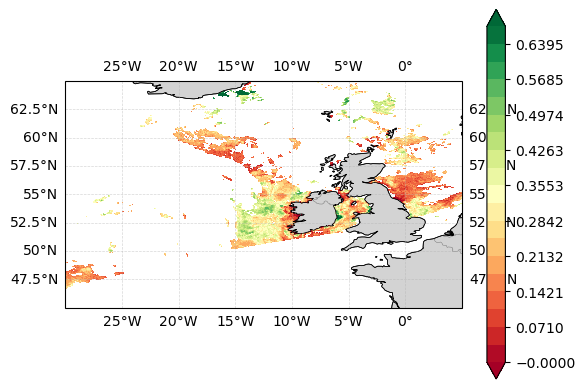

In [31]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = -30 # np.min(lon_pace) - buffer_bnd
lon_max = 5  # np.max(lon_pace) + buffer_bnd
lat_min = 45 # np.min(lat_pace) - buffer_bnd
lat_max = 65 # np.max(lat_pace) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extend, crs=ccrs.PlateCarree())  # Global

# Plot nFLH data using contourf
levels = np.linspace(np.nanpercentile(nflh_pace, .5), np.nanpercentile(nflh_pace, 99.5), 20)
im = ax.contourf(lon_pace, lat_pace, nflh_pace, 
                 levels=levels,
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 extend='both')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

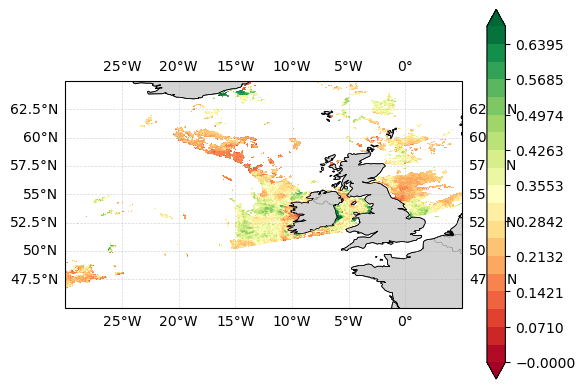

In [32]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
# buffer_bnd = .25
# lon_min = np.min(lon) - buffer_bnd
# lon_max = np.max(lon) + buffer_bnd
# lat_min = np.min(lat) - buffer_bnd
# lat_max = np.max(lat) + buffer_bnd
# extend = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extend, crs=ccrs.PlateCarree())  # Global

# Plot nFLH data using contourf
levels = np.linspace(np.nanpercentile(nflh_pace, .5), np.nanpercentile(nflh_pace, 99.5), 20)
im = ax.contourf(lon, lat, sif_recon, 
                 levels=levels,
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 extend='both')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

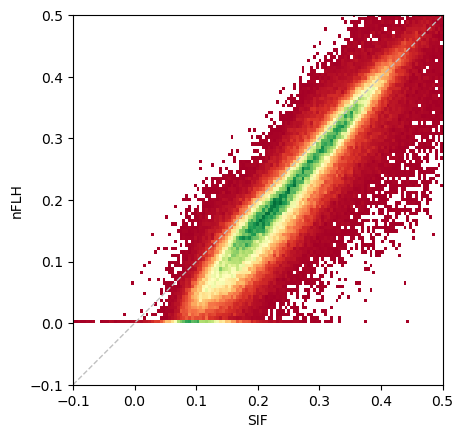

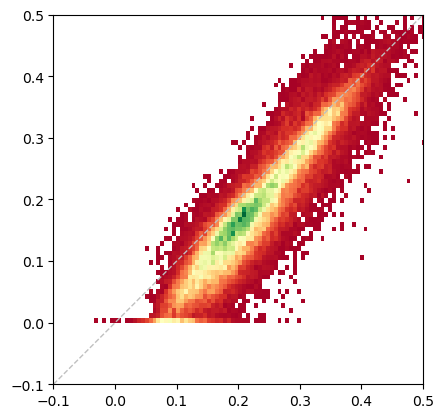

In [47]:
# density kernel plot of nflh vs. sif_recon
fig, ax = plt.subplots()
sns.histplot(x = sif_recon.flatten(), y = nflh_pace.flatten(), ax=ax, cmap='RdYlGn', fill=True)
ax.set_xlim(-.1, .5)
ax.set_ylim(-.1, .5)
ax.set_aspect('equal')
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='silver', ls='--', linewidth=1)
ax.set_xlabel('SIF')
ax.set_ylabel('nFLH')
plt.show()

# another figure showing only the converged pixels
fig, ax = plt.subplots()
sns.histplot(x = sif_recon[converged == 1].flatten(), y = nflh_pace[converged == 1].flatten(), ax=ax, cmap='RdYlGn', fill=True)
ax.set_xlim(-.1, .5)
ax.set_ylim(-.1, .5)
ax.set_aspect('equal')
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='silver', ls='--', linewidth=1)